# AI-Powered Customer Segmentation & Customer Lifetime Value Analysis

## 1. Project Overview
This project analyzes customer purchasing behavior using Python, RFM analysis, K-Means clustering, and Customer Lifetime Value (CLV).

### Objectives
- Understand customer purchasing behavior
- Segment customers based on their behavior
- Identify high-value and at-risk customers
- Estimate Customer Lifetime Value
- Generate actionable business recommendations

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving customer_transactions.csv to customer_transactions.csv


## 2. Data Loading & Understanding


In [ ]:
# Import DataSheet
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_transactions.csv')
print(df)

      InvoiceNo CustomerID InvoiceDate       Product  Quantity  UnitPrice  \
0     INV000001   CUST0103  2024-02-24     USB Cable         5    5465.66   
1     INV000002   CUST0436  2024-06-30    Smartwatch         5    1428.66   
2     INV000003   CUST0271  2024-07-28  Gaming Chair         1    3386.60   
3     INV000004   CUST0107  2024-03-15        Tablet         1    1770.80   
4     INV000005   CUST0072  2024-10-03        Laptop         2   11167.22   
...         ...        ...         ...           ...       ...        ...   
5015  INV003544   CUST0664  2024-07-26    Power Bank         5    1292.41   
5016  INV001074   CUST0023  2024-11-12    Headphones         4     261.22   
5017  INV003352   CUST0153  2024-05-20    Smartwatch         5   12390.02   
5018  INV001745   CUST0430  2024-04-02      Keyboard         5    1819.49   
5019  INV001085   CUST0646  2024-07-26        Laptop         4    3255.16   

     Country     Sales  
0        UAE  27328.30  
1         UK   7143.30  


In [ ]:
# Datasheet information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    5020 non-null   object 
 1   CustomerID   4970 non-null   object 
 2   InvoiceDate  5020 non-null   object 
 3   Product      5020 non-null   object 
 4   Quantity     5020 non-null   int64  
 5   UnitPrice    5020 non-null   float64
 6   Country      5020 non-null   object 
 7   Sales        5020 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 313.9+ KB


In [ ]:
# check missing values
df.isnull().sum()

,0
InvoiceNo,0
CustomerID,50
InvoiceDate,0
Product,0
Quantity,0
UnitPrice,0
Country,0
Sales,0


In [ ]:
#Chexk duplicates Values
df.duplicated().sum()

np.int64(20)

In [ ]:
# Removing duplicates Values
df=df.drop_duplicates()
print("Rows after removing duplicates:",len(df))

Rows after removing duplicates: 5000


In [ ]:
# Handle Missing Values
df = df.dropna(subset=["CustomerID"])
print("Rows after removing missing CustomerID:", len(df))

Rows after removing missing CustomerID: 4950


In [ ]:
# Data column Convert
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
print(df.dtypes)

InvoiceNo              object
CustomerID             object
InvoiceDate    datetime64[ns]
Product                object
Quantity                int64
UnitPrice             float64
Country                object
Sales                 float64
dtype: object


In [ ]:
# Basic Statistical Summary
df.describe()

,InvoiceDate,Quantity,UnitPrice,Sales
count,4950,4950.000000,4950.000000,4950.000000
mean,2024-07-01 03:22:10.909090816,2.974545,3484.139430,10454.758196
min,2024-01-01 00:00:00,1.000000,254.180000,258.140000
25%,2024-04-02 00:00:00,2.000000,781.942500,1749.427500
50%,2024-07-02 00:00:00,3.000000,1716.440000,4526.990000
75%,2024-10-01 00:00:00,4.000000,4936.657500,13158.575000
max,2024-12-31 00:00:00,5.000000,14945.910000,74729.550000
std,NaN,1.411553,3901.540464,13948.923549


In [ ]:
# Unique Customers & Products
print("Unique Customers:", df["CustomerID"].nunique())
print("Unique Products:", df["Product"].nunique())
print("Unique Countries:", df["Country"].nunique())

Unique Customers: 750
Unique Products: 12
Unique Countries: 6


In [ ]:
# Sales Distribution by Product
product_sales=df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
print(product_sales)

Product
Mouse                4945988.67
Power Bank           4778641.28
Monitor              4707102.30
USB Cable            4671306.68
Smartwatch           4347565.39
Gaming Chair         4310415.92
Bluetooth Speaker    4300441.57
Laptop               4169154.63
Headphones           3995467.09
Tablet               3980978.78
Keyboard             3929137.54
Smartphone           3614853.22
Name: Sales, dtype: float64


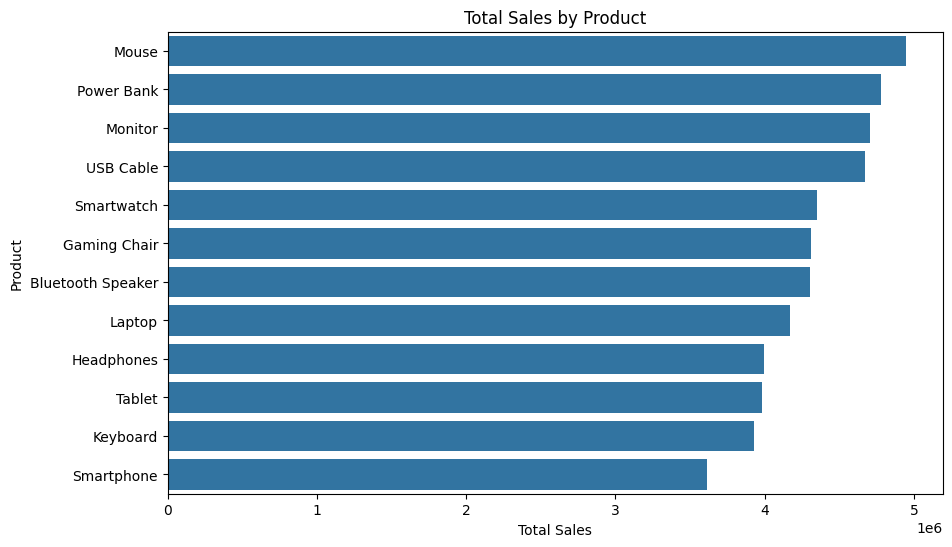

In [ ]:
# Product Sales Visualization
plt.figure(figsize=(10,6))
sns.barplot(
    x=product_sales.values,
    y=product_sales.index
)
plt.title("Total Sales by Product")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

In [ ]:
# Customer Purchase Analysis
customer_sales=(
    df.groupby("CustomerID")["Sales"].sum()
    .sort_values(ascending=False)
)
print(customer_sales.head(10))

CustomerID
CUST0277    286590.37
CUST0318    250847.96
CUST0118    239570.24
CUST0511    219895.56
CUST0400    216723.28
CUST0261    198773.93
CUST0666    195157.79
CUST0285    194835.21
CUST0153    193293.65
CUST0524    192248.34
Name: Sales, dtype: float64


In [ ]:
# Reference date for RFM analysis
reference_date=df["InvoiceDate"].max()+pd.Timedelta(days=1)

print("Reference Date :",reference_date)

Reference Date : 2025-01-01 00:00:00


In [ ]:
#  RFM Table
rfm=df.groupby("CustomerID").agg(
    Recency=("InvoiceDate",lambda x:(reference_date-x.max()).days),
    Frequency=("InvoiceNo","nunique"),
    Monetary=("Sales","sum")

)
print(rfm.head(10))

            Recency  Frequency   Monetary
CustomerID                               
CUST0001         32         10  156651.08
CUST0002        167          6   27457.70
CUST0003         87          8   39098.82
CUST0004         65          3    5924.14
CUST0005         28          6   44208.98
CUST0006         82          2    7018.49
CUST0007         27          9   99404.00
CUST0008         57          8  123524.74
CUST0009        120          3   78008.12
CUST0010         52          9  112541.32


In [ ]:
# RFM Scoring

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
CUST0001,32,10,156651.08,3,5,5
CUST0002,167,6,27457.70,1,2,1
CUST0003,87,8,39098.82,2,4,2
CUST0004,65,3,5924.14,2,1,1
CUST0005,28,6,44208.98,4,2,2
CUST0006,82,2,7018.49,2,1,1
CUST0007,27,9,99404.00,4,4,4
CUST0008,57,8,123524.74,2,4,5
CUST0009,120,3,78008.12,1,1,4


In [ ]:
# Combine RFM Scores

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
CUST0001,32,10,156651.08,3,5,5,355
CUST0002,167,6,27457.70,1,2,1,121
CUST0003,87,8,39098.82,2,4,2,242
CUST0004,65,3,5924.14,2,1,1,211
CUST0005,28,6,44208.98,4,2,2,422
CUST0006,82,2,7018.49,2,1,1,211
CUST0007,27,9,99404.00,4,4,4,444
CUST0008,57,8,123524.74,2,4,5,245
CUST0009,120,3,78008.12,1,1,4,114


In [ ]:
# Customer Segmentation

def segment_customer(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Lost Customers"
    else:
        return "Potential Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
CUST0001,32,10,156651.08,3,5,5,355,Loyal Customers
CUST0002,167,6,27457.70,1,2,1,121,Lost Customers
CUST0003,87,8,39098.82,2,4,2,242,At Risk
CUST0004,65,3,5924.14,2,1,1,211,Lost Customers
CUST0005,28,6,44208.98,4,2,2,422,New Customers
CUST0006,82,2,7018.49,2,1,1,211,Lost Customers
CUST0007,27,9,99404.00,4,4,4,444,Champions
CUST0008,57,8,123524.74,2,4,5,245,At Risk
CUST0009,120,3,78008.12,1,1,4,114,Lost Customers


Segment
Loyal Customers        214
Lost Customers         172
At Risk                127
Champions              109
New Customers           79
Potential Customers     49
Name: count, dtype: int64


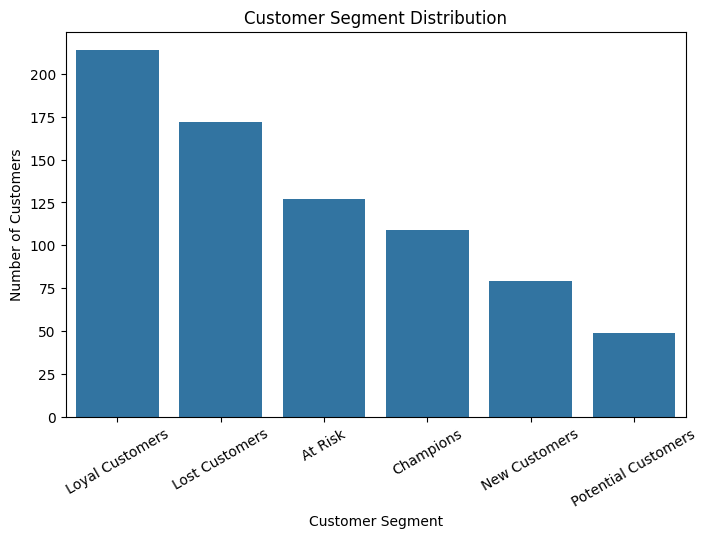

In [ ]:
segment_count=rfm["Segment"].value_counts()

print(segment_count)

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_count.index,
    y=segment_count.values
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select RFM features
X = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (750, 3)


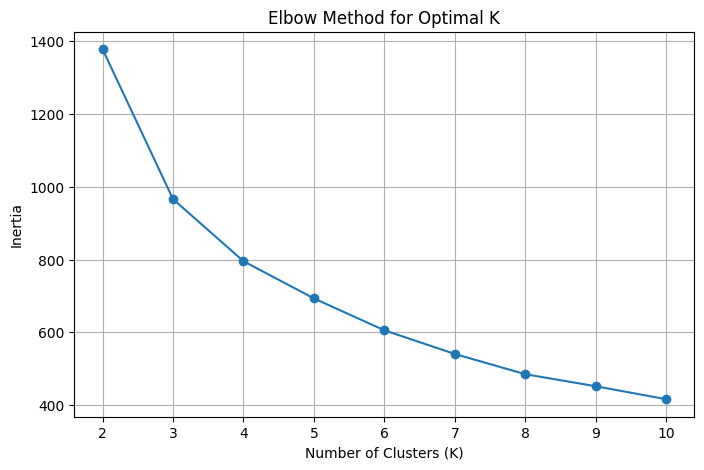

In [ ]:
# Elbow Method

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [ ]:
# K-Means Customer Clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print(rfm["Cluster"].value_counts().sort_index())

Cluster
0    251
1    264
2     96
3    139
Name: count, dtype: int64


In [ ]:
# Cluster Profiling

cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

print(cluster_profile)

         Recency  Frequency   Monetary
Cluster                               
0          49.49       4.65   34456.97
1          33.83       7.66   72751.26
2         167.54       4.03   45558.31
3          32.44       9.88  140449.09


In [ ]:
# Cluster Profiling

cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

print(cluster_profile)

         Recency  Frequency   Monetary
Cluster                               
0          49.49       4.65   34456.97
1          33.83       7.66   72751.26
2         167.54       4.03   45558.31
3          32.44       9.88  140449.09


In [ ]:
rfm = rfm.reset_index()

In [ ]:
# Assign Business Names to AI Clusters

cluster_names = {
    0: "Low Value Customers",
    1: "Loyal Customers",
    2: "At Risk Customers",
    3: "VIP Customers"
}

rfm["AI_Segment"] = rfm["Cluster"].map(cluster_names)

print(rfm[
    [
        "CustomerID",
        "RFM_Score",
        "Cluster",
        "AI_Segment"
    ]
].head(10))

  CustomerID RFM_Score  Cluster           AI_Segment
0   CUST0001       355        3        VIP Customers
1   CUST0002       121        2    At Risk Customers
2   CUST0003       242        1      Loyal Customers
3   CUST0004       211        0  Low Value Customers
4   CUST0005       422        0  Low Value Customers
5   CUST0006       211        0  Low Value Customers
6   CUST0007       444        1      Loyal Customers
7   CUST0008       245        3        VIP Customers
8   CUST0009       114        2    At Risk Customers
9   CUST0010       245        3        VIP Customers


In [ ]:
print(rfm.dtypes)

CustomerID     object
Recency         int64
Frequency       int64
Monetary      float64
R_Score         int64
F_Score         int64
M_Score         int64
RFM_Score      object
Segment        object
Cluster         int32
AI_Segment     object
dtype: object


In [ ]:
# Convert RFM Score to numeric
rfm["RFM_Score"] = pd.to_numeric(rfm["RFM_Score"], errors="coerce")

print(rfm.dtypes)

CustomerID     object
Recency         int64
Frequency       int64
Monetary      float64
R_Score         int64
F_Score         int64
M_Score         int64
RFM_Score       int64
Segment        object
Cluster         int32
AI_Segment     object
dtype: object


In [ ]:
# Segment-wise Business Analysis

segment_analysis = rfm.groupby("AI_Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Avg_RFM_Score=("RFM_Score", "mean")
).round(2)

print(segment_analysis)

                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
AI_Segment                                                                 
At Risk Customers           96       167.54           4.03      45558.31   
Low Value Customers        251        49.49           4.65      34456.97   
Loyal Customers            264        33.83           7.66      72751.26   
VIP Customers              139        32.44           9.88     140449.09   

                     Avg_RFM_Score  
AI_Segment                          
At Risk Customers           118.78  
Low Value Customers         308.09  
Loyal Customers             397.44  
VIP Customers               411.46  


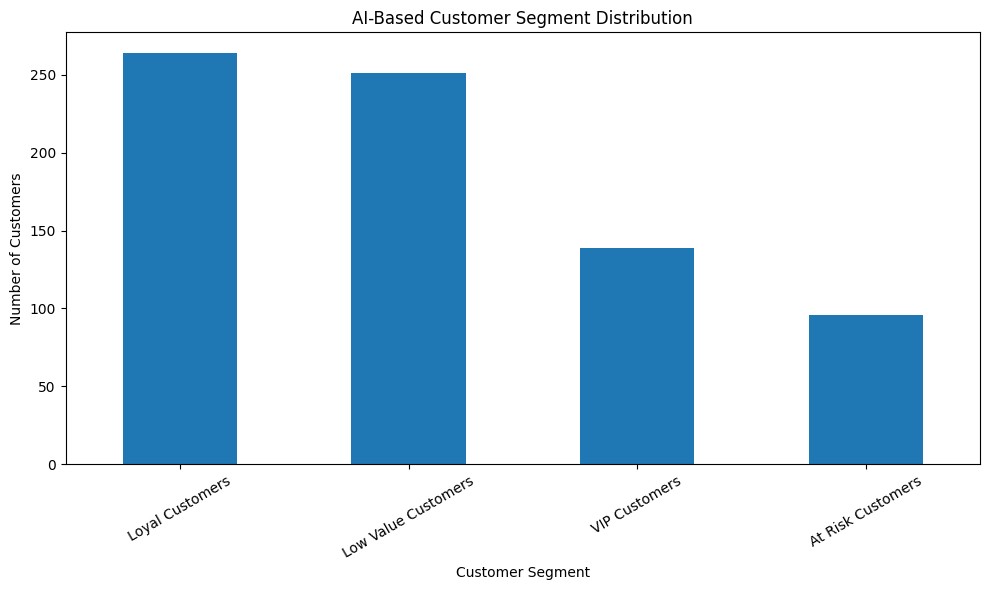

In [ ]:
# AI Segment Visualization
import matplotlib.pyplot as plt

segment_counts = rfm["AI_Segment"].value_counts()

plt.figure(figsize=(10, 6))
segment_counts.plot(kind="bar")

plt.title("AI-Based Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# Customer Lifetime Value Calculation

customer_metrics = rfm.groupby("CustomerID").agg(
    Total_Sales=("Monetary", "sum"),
    Purchase_Frequency=("Frequency", "mean")
).reset_index()

customer_metrics["Avg_Order_Value"] = (
    customer_metrics["Total_Sales"] /
    customer_metrics["Purchase_Frequency"]
)

customer_metrics.head(10)

,CustomerID,Total_Sales,Purchase_Frequency,Avg_Order_Value
0,CUST0001,156651.08,10.0,15665.108000
1,CUST0002,27457.70,6.0,4576.283333
2,CUST0003,39098.82,8.0,4887.352500
3,CUST0004,5924.14,3.0,1974.713333
4,CUST0005,44208.98,6.0,7368.163333
5,CUST0006,7018.49,2.0,3509.245000
6,CUST0007,99404.00,9.0,11044.888889
7,CUST0008,123524.74,8.0,15440.592500
8,CUST0009,78008.12,3.0,26002.706667
9,CUST0010,112541.32,9.0,12504.591111


In [ ]:
# Estimate Customer Lifetime Value

customer_metrics["Customer_Lifespan_Years"] = 2

customer_metrics["Estimated_CLV"] = (
    customer_metrics["Avg_Order_Value"] *
    customer_metrics["Purchase_Frequency"] *
    customer_metrics["Customer_Lifespan_Years"]
)

customer_metrics[[
    "CustomerID",
    "Avg_Order_Value",
    "Purchase_Frequency",
    "Customer_Lifespan_Years",
    "Estimated_CLV"
]].head(10)

,CustomerID,Avg_Order_Value,Purchase_Frequency,Customer_Lifespan_Years,Estimated_CLV
0,CUST0001,15665.108000,10.0,2,313302.16
1,CUST0002,4576.283333,6.0,2,54915.40
2,CUST0003,4887.352500,8.0,2,78197.64
3,CUST0004,1974.713333,3.0,2,11848.28
4,CUST0005,7368.163333,6.0,2,88417.96
5,CUST0006,3509.245000,2.0,2,14036.98
6,CUST0007,11044.888889,9.0,2,198808.00
7,CUST0008,15440.592500,8.0,2,247049.48
8,CUST0009,26002.706667,3.0,2,156016.24
9,CUST0010,12504.591111,9.0,2,225082.64


In [ ]:
# Check available variables containing "clv"

print([x for x in globals() if "clv" in x.lower()])

[]


In [ ]:
print([x for x in globals() if 'customer' in x.lower()])

['customer_sales', 'segment_customer', 'customer_metrics']


In [ ]:
print(customer_metrics.columns)
print(customer_metrics.head())

Index(['CustomerID', 'Total_Sales', 'Purchase_Frequency', 'Avg_Order_Value',
       'Customer_Lifespan_Years', 'Estimated_CLV'],
      dtype='object')
  CustomerID  Total_Sales  Purchase_Frequency  Avg_Order_Value  \
0   CUST0001    156651.08                10.0     15665.108000   
1   CUST0002     27457.70                 6.0      4576.283333   
2   CUST0003     39098.82                 8.0      4887.352500   
3   CUST0004      5924.14                 3.0      1974.713333   
4   CUST0005     44208.98                 6.0      7368.163333   

   Customer_Lifespan_Years  Estimated_CLV  
0                        2      313302.16  
1                        2       54915.40  
2                        2       78197.64  
3                        2       11848.28  
4                        2       88417.96  


In [ ]:
# Top 10 Customers by Estimated CLV

top_clv = customer_metrics.sort_values(
    "Estimated_CLV",
    ascending=False
).head(10)

print(top_clv[
    ["CustomerID", "Total_Sales", "Purchase_Frequency",
     "Avg_Order_Value", "Estimated_CLV"]
])

    CustomerID  Total_Sales  Purchase_Frequency  Avg_Order_Value  \
276   CUST0277    286590.37                13.0     22045.413077   
317   CUST0318    250847.96                13.0     19295.996923   
117   CUST0118    239570.24                12.0     19964.186667   
510   CUST0511    219895.56                 9.0     24432.840000   
399   CUST0400    216723.28                 7.0     30960.468571   
260   CUST0261    198773.93                 9.0     22085.992222   
665   CUST0666    195157.79                10.0     19515.779000   
284   CUST0285    194835.21                 8.0     24354.401250   
152   CUST0153    193293.65                 7.0     27613.378571   
523   CUST0524    192248.34                 8.0     24031.042500   

     Estimated_CLV  
276      573180.74  
317      501695.92  
117      479140.48  
510      439791.12  
399      433446.56  
260      397547.86  
665      390315.58  
284      389670.42  
152      386587.30  
523      384496.68  


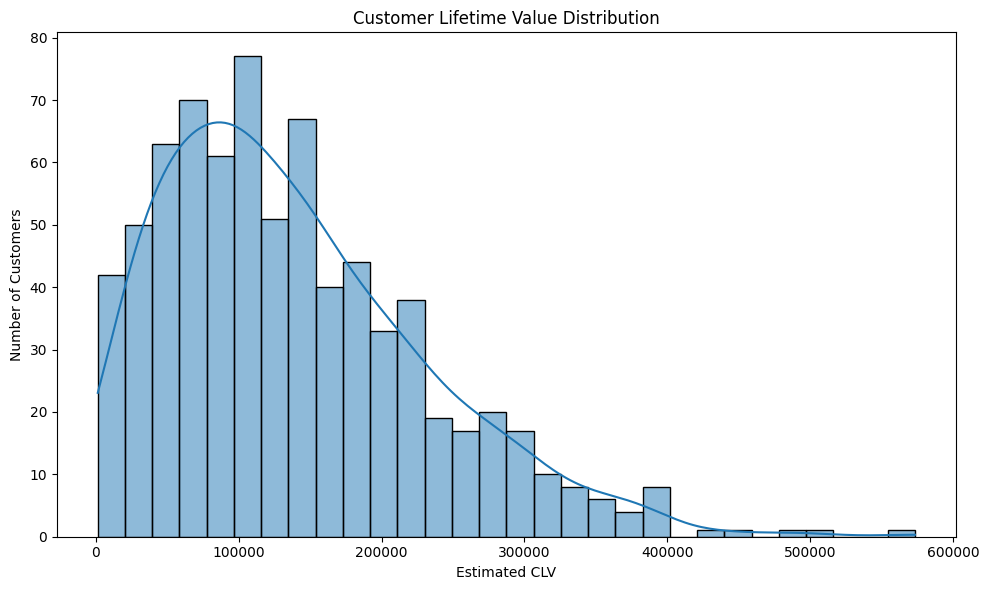

In [ ]:
# CLV Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    customer_metrics["Estimated_CLV"],
    bins=30,
    kde=True
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Estimated CLV")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [ ]:
# Average CLV by AI Customer Segment

segment_clv = rfm.merge(
    customer_metrics[["CustomerID", "Estimated_CLV"]],
    on="CustomerID",
    how="left"
)

avg_clv_segment = segment_clv.groupby("AI_Segment")["Estimated_CLV"].mean().sort_values(
    ascending=False
)

print(avg_clv_segment)

AI_Segment
VIP Customers          280898.176403
Loyal Customers        145502.519091
At Risk Customers       91116.620625
Low Value Customers     68913.940239
Name: Estimated_CLV, dtype: float64


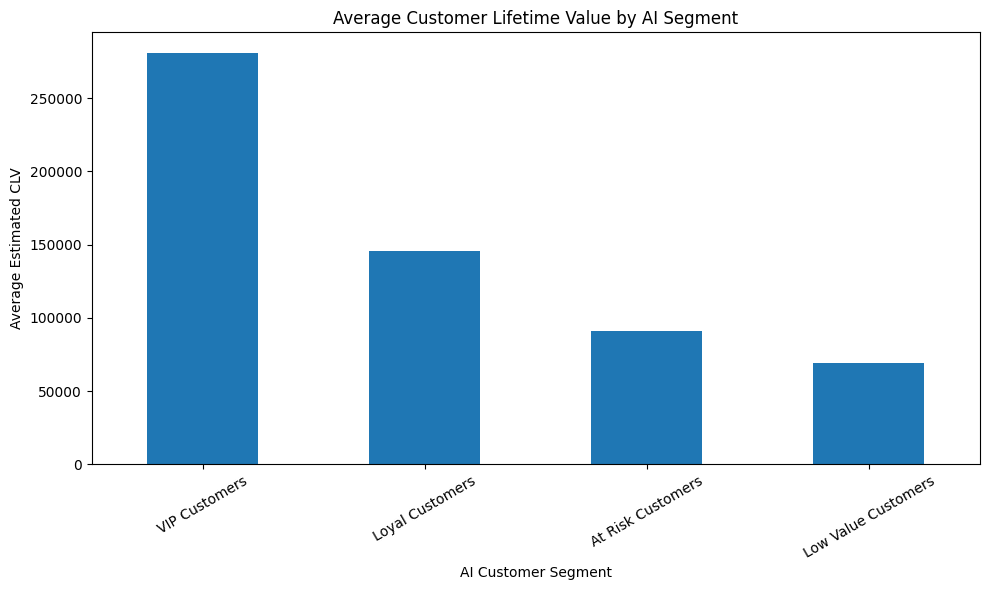

In [ ]:
# Average CLV by AI Customer Segment

plt.figure(figsize=(10, 6))

avg_clv_segment.plot(kind="bar")

plt.title("Average Customer Lifetime Value by AI Segment")
plt.xlabel("AI Customer Segment")
plt.ylabel("Average Estimated CLV")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# Business Recommendations for AI Customer Segments

recommendations = {
    "VIP Customers": "Exclusive offers, premium products, loyalty rewards and personalized services",
    "Loyal Customers": "Loyalty programs, cross-selling, upselling and repeat-purchase offers",
    "At Risk Customers": "Re-engagement campaigns, personalized discounts and targeted reminders",
    "Low Value Customers": "Entry-level offers, product recommendations and low-cost promotional campaigns"
}

rfm["Recommendation"] = rfm["AI_Segment"].map(recommendations)

print(
    rfm[
        ["CustomerID", "AI_Segment", "RFM_Score", "Recommendation"]
    ].head(10)
)

  CustomerID           AI_Segment  RFM_Score  \
0   CUST0001        VIP Customers        355   
1   CUST0002    At Risk Customers        121   
2   CUST0003      Loyal Customers        242   
3   CUST0004  Low Value Customers        211   
4   CUST0005  Low Value Customers        422   
5   CUST0006  Low Value Customers        211   
6   CUST0007      Loyal Customers        444   
7   CUST0008        VIP Customers        245   
8   CUST0009    At Risk Customers        114   
9   CUST0010        VIP Customers        245   

                                      Recommendation  
0  Exclusive offers, premium products, loyalty re...  
1  Re-engagement campaigns, personalized discount...  
2  Loyalty programs, cross-selling, upselling and...  
3  Entry-level offers, product recommendations an...  
4  Entry-level offers, product recommendations an...  
5  Entry-level offers, product recommendations an...  
6  Loyalty programs, cross-selling, upselling and...  
7  Exclusive offers, premium pr

In [ ]:
# Final AI Segment Business Summary

business_summary = rfm.groupby("AI_Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_RFM_Score=("RFM_Score", "mean")
).round(2)

business_summary["Avg_CLV"] = (
    segment_clv.groupby("AI_Segment")["Estimated_CLV"]
    .mean()
    .round(2)
)

business_summary["Recommendation"] = business_summary.index.map(recommendations)

print(business_summary)

                     Customers  Avg_RFM_Score    Avg_CLV  \
AI_Segment                                                 
At Risk Customers           96         118.78   91116.62   
Low Value Customers        251         308.09   68913.94   
Loyal Customers            264         397.44  145502.52   
VIP Customers              139         411.46  280898.18   

                                                        Recommendation  
AI_Segment                                                              
At Risk Customers    Re-engagement campaigns, personalized discount...  
Low Value Customers  Entry-level offers, product recommendations an...  
Loyal Customers      Loyalty programs, cross-selling, upselling and...  
VIP Customers        Exclusive offers, premium products, loyalty re...  


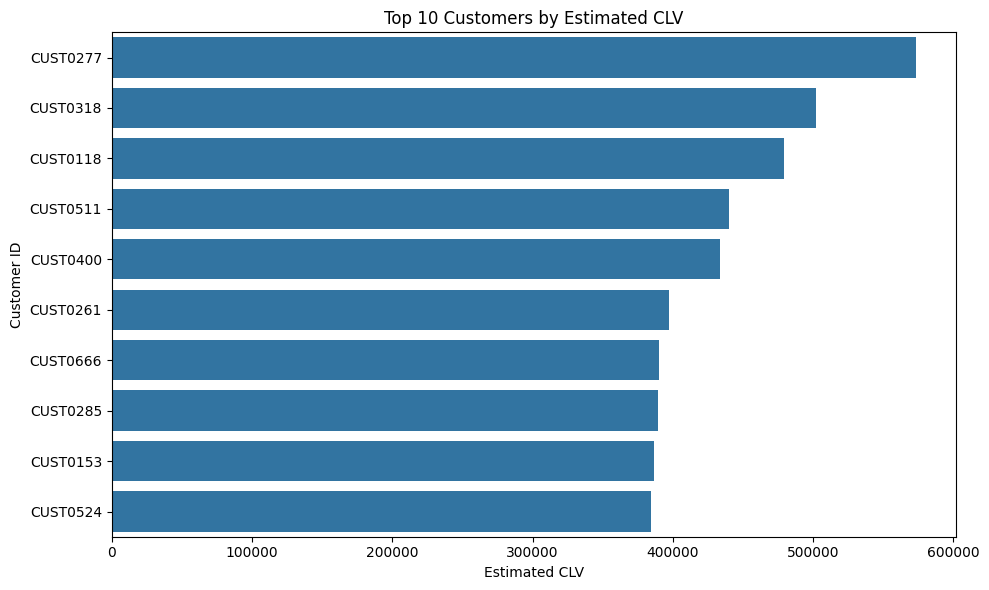

In [ ]:
# Top 10 Customers by Estimated CLV

top_clv = customer_metrics.sort_values(
    "Estimated_CLV",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_clv,
    x="Estimated_CLV",
    y="CustomerID"
)

plt.title("Top 10 Customers by Estimated CLV")
plt.xlabel("Estimated CLV")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

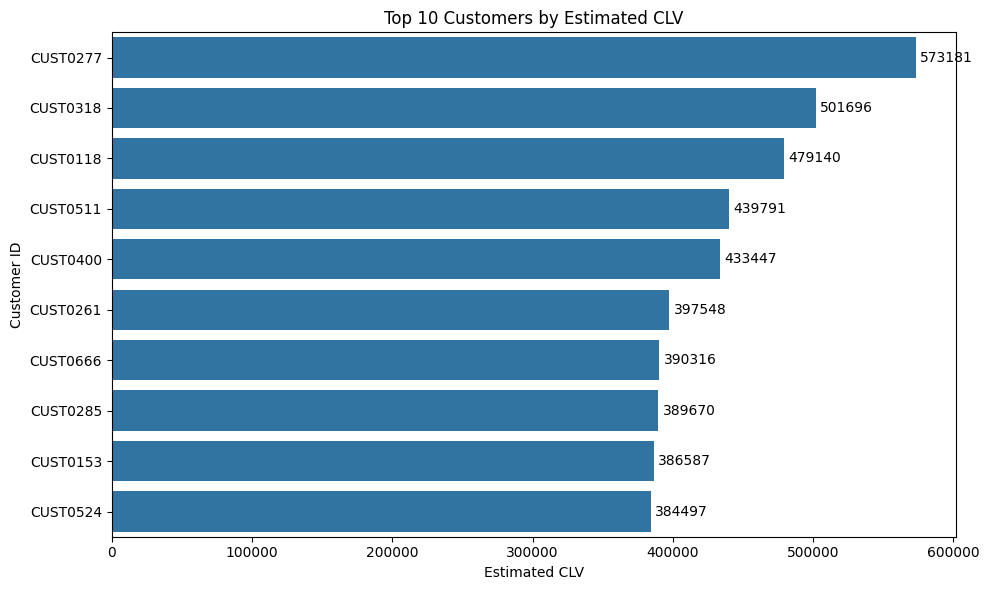

In [ ]:
# Top 10 Customers by Estimated CLV

top_clv = customer_metrics.sort_values(
    "Estimated_CLV",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_clv,
    x="Estimated_CLV",
    y="CustomerID"
)

plt.title("Top 10 Customers by Estimated CLV")
plt.xlabel("Estimated CLV")
plt.ylabel("Customer ID")

# Add values to bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

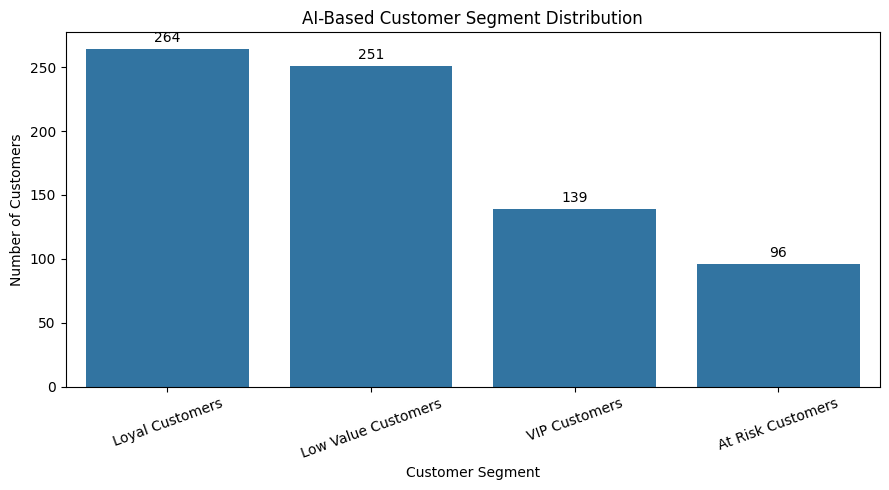

In [ ]:
# AI Customer Segment Distribution

ai_segment_counts = rfm["AI_Segment"].value_counts()

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=ai_segment_counts.index,
    y=ai_segment_counts.values
)

plt.title("AI-Based Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

# Add customer counts
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

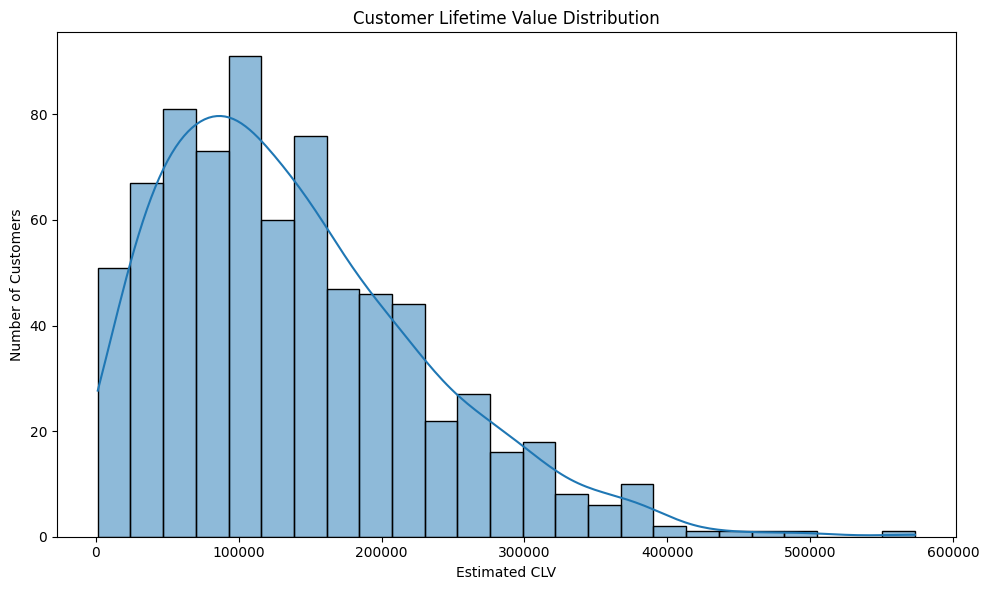

In [ ]:
# Customer Lifetime Value Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    customer_metrics["Estimated_CLV"],
    bins=25,
    kde=True
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Estimated CLV")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()